##Instacart 신규 고객 장기전환 — 개입 시점 분석



## 분석 개요

Instacart는 반복 구매에 매출이 집중되는 식료품 배달 플랫폼.  
고객이 앱을 지속적으로 사용할수록 수익에 직결되는 구조.

신규 고객 중 일부만 장기고객으로 전환되며, 나머지는 장기전환에 이르지 못함.  
전환 여부가 초반 구매 행동에서 이미 드러난다면,  
**이탈 전 시점을 데이터로 찾아내 집중 개입 → 장기전환율 상승.**

> **초반 구매 데이터로 이탈 위험 고객을 조기에 식별하고,  
> 장기전환율을 높이기 위한 최적 개입 시점을 데이터로 정의할 수 있는가?**

---

## 데이터셋

- 출처: Kaggle — Instacart Market Basket Analysis (2017)
- 규모: 주문 342만 건 / 고객 206,209명 / 상품 49,688개
- 파일: orders.csv / order_products__prior.csv / order_products__train.csv / products.csv / aisles.csv / departments.csv

---

## 분석 흐름

1. **H1** 장기고객 기준 설정 — 재주문율 곡선으로 전환 임계점 도출
2. **H2** 기준 타당성 검증 — 장기/비장기 그룹 간 초반 행동 차이 확인
3. **H3** 최적 개입 차수 탐색 — 예측력과 타이밍의 균형점 구간 확정
4. **H4** 전환 예측 모델 구축 — 초기 주문 간격 기반 로지스틱 회귀
5. **H5** 개입 구간 수치화 — ROC Curve 기반 하한선/상한선 도출
6. **H6** 결론 및 마케팅 제언 — 개입 대상 고객 식별 및 전략 제시

In [ ]:
# ============================================================
# SETUP — 환경 설치 / 경로 / 상수 (최초 1회 실행)
# ============================================================
import subprocess, sys

subprocess.run(["apt-get", "-qq", "install", "fonts-nanum"], check=False, capture_output=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kneed", "lifelines"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=False)

# 경로 — Colab / 로컬 자동 분기
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset/'
except ImportError:
    BASE_PATH = './data/'

# 시각화 컬러
COLORS = ['#C2FF00', '#A8E600', '#8FCC00', '#76B300']

# 분석 상수 — 각 섹션에서 데이터 기반으로 확정
THRESHOLD        = None   # H1에서 확정: 장기고객 전환 임계점 (→ 19)
BEST_TIMING_MIN  = None   # H3에서 확정: 개입 구간 시작 차수 (→ 4)
BEST_TIMING_MAX  = None   # H3에서 확정: 개입 구간 종료 차수 (→ 6)
BEST_TIMING      = None   # H3에서 확정: 대표 차수 (→ 5)

print(f"BASE_PATH: {BASE_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_PATH: /content/drive/MyDrive/Colab Notebooks/dataset/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 — 6개 파일 최초 1회 (이후 재로드 금지)
orders   = pd.read_csv(BASE_PATH + 'orders.csv')
prior    = pd.read_csv(BASE_PATH + 'order_products__prior.csv')
train    = pd.read_csv(BASE_PATH + 'order_products__train.csv')
products = pd.read_csv(BASE_PATH + 'products.csv')
aisles   = pd.read_csv(BASE_PATH + 'aisles.csv')
depts    = pd.read_csv(BASE_PATH + 'departments.csv')

for name, df in [('orders',orders),('prior',prior),('train',train),
                 ('products',products),('aisles',aisles),('depts',depts)]:
    print(f"{name:12s}: {df.shape[0]:>9,}행  {df.shape[1]}열")

orders      : 3,421,083행  7열
prior       : 32,434,489행  4열
train       : 1,384,617행  4열
products    :    49,688행  4열
aisles      :       134행  2열
depts       :        21행  2열


In [ ]:
# 결측치 검증
for name, df in [('orders',orders),('prior',prior),('train',train),
                 ('products',products),('aisles',aisles),('depts',depts)]:
    null_cols = df.isnull().sum()
    null_cols = null_cols[null_cols > 0]
    if not null_cols.empty:
        print(f"[{name}] 결측치:")
        print(null_cols)
    else:
        print(f"[{name}] 결측치 없음")

# days_since_prior_order 결측치 검증
first_orders = orders[orders['order_number'] == 1]
print(f"\n첫 주문 행 수            : {len(first_orders):,}")
print(f"days_since_prior_order 결측치: {orders['days_since_prior_order'].isnull().sum():,}")

[orders] 결측치:
days_since_prior_order    206209
dtype: int64
[prior] 결측치 없음
[train] 결측치 없음
[products] 결측치 없음
[aisles] 결측치 없음
[depts] 결측치 없음

첫 주문 행 수            : 206,209
days_since_prior_order 결측치: 206,209


## 데이터 품질 점검 결과

- `days_since_prior_order` 결측치 206,209건 = 전체 고객 수와 일치
  → 각 고객의 첫 번째 주문(이전 주문이 없으므로 정상 결측), 분석 시 제외 처리
- 나머지 5개 파일 결측치 없음

In [ ]:
import duckdb

# pandas 데이터프레임을 SQL 테이블로 등록
con = duckdb.connect()
con.register('orders_t', orders)
con.register('prior_t', prior)
con.register('train_t', train)

user_stats = con.execute("""
    WITH order_products AS (
        -- prior + train 주문 상품 통합
        SELECT order_id, reordered FROM prior_t
        UNION ALL
        SELECT order_id, reordered FROM train_t
    ),
    reorder_agg AS (
        -- 유저별 평균 재주문율
        SELECT o.user_id, AVG(op.reordered) AS reorder_rate
        FROM order_products op
        JOIN orders_t o ON op.order_id = o.order_id
        GROUP BY o.user_id
    ),
    order_count AS (
        -- 유저별 총 주문 횟수
        SELECT user_id, MAX(order_number) AS total_orders
        FROM orders_t
        GROUP BY user_id
    ),
    interval_agg AS (
        -- 유저별 평균 주문 간격 (첫 주문 제외)
        SELECT user_id, AVG(days_since_prior_order) AS avg_interval
        FROM orders_t
        WHERE days_since_prior_order IS NOT NULL
        GROUP BY user_id
    )
    SELECT r.user_id, r.reorder_rate, o.total_orders, i.avg_interval
    FROM reorder_agg r
    JOIN order_count o ON r.user_id = o.user_id
    JOIN interval_agg i ON r.user_id = i.user_id
""").df()

print(f"유저 수: {len(user_stats):,}")
print(user_stats[['reorder_rate', 'total_orders', 'avg_interval']].describe().round(2))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

유저 수: 206,209
       reorder_rate  total_orders  avg_interval
count     206209.00     206209.00     206209.00
mean           0.44         16.59         15.45
std            0.21         16.65          6.92
min            0.00          4.00          0.00
25%            0.29          6.00          9.81
50%            0.44         10.00         15.00
75%            0.60         20.00         20.62
max            0.99        100.00         30.00


## 유저 기본 통계 요약

- **재주문율** 평균 0.43 / 중앙값 0.43 — 정규분포에 가까운 형태
- **총 주문 횟수** 평균 16.59 / 중앙값 10 — 소수 헤비유저가 평균을 끌어올린 우측 꼬리 분포. 단순 평균이 대표값이 될 수 없어 분포 기반 분석 필요
- **평균 주문 간격** 평균 15.45일 / 중앙값 15일
  - `days_since_prior_order`는 데이터셋 설계상 30일을 초과하는 값이 모두 30으로 기록됨
  - 실제 간격이 30일을 넘는 고객의 주문 간격이 과소 추정되며, 분포에서 30일 구간에 스파이크로 나타남
  - 이후 주문 간격 기반 분석에서 이 한계를 명시적으로 고려

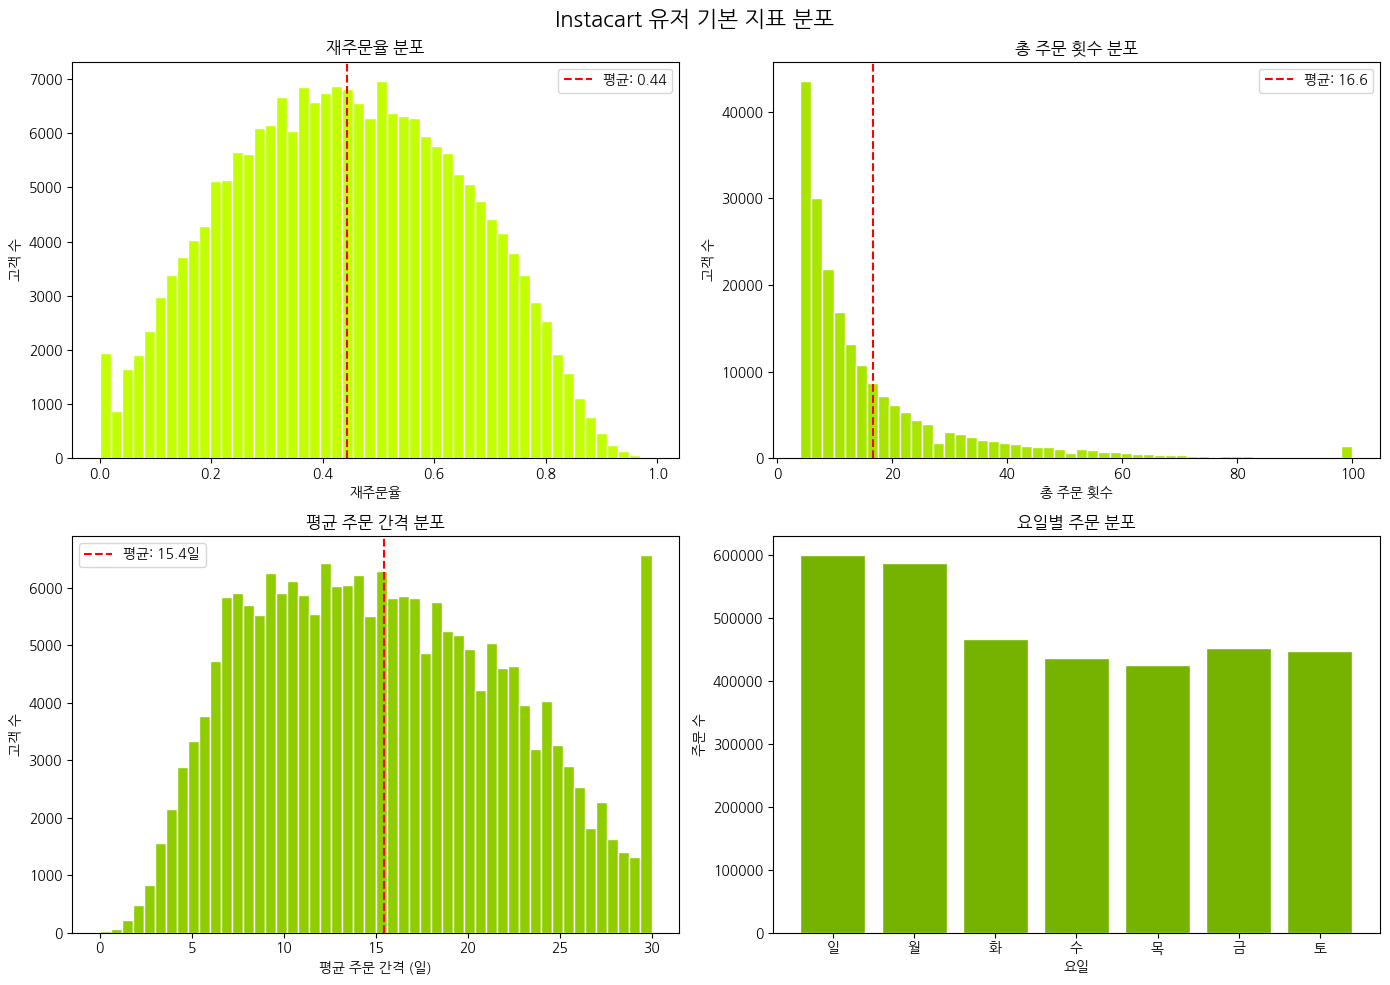

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Instacart 유저 기본 지표 분포', fontsize=16, fontweight='bold')

# 1. 재주문율 분포
axes[0, 0].hist(user_stats['reorder_rate'], bins=50, color=COLORS[0], edgecolor='white')
axes[0, 0].axvline(user_stats['reorder_rate'].mean(), color='red', linestyle='--',
                   label=f"평균: {user_stats['reorder_rate'].mean():.2f}")
axes[0, 0].set_title('재주문율 분포')
axes[0, 0].set_xlabel('재주문율')
axes[0, 0].set_ylabel('고객 수')
axes[0, 0].legend()

# 2. 총 주문 횟수 분포
axes[0, 1].hist(user_stats['total_orders'], bins=50, color=COLORS[1], edgecolor='white')
axes[0, 1].axvline(user_stats['total_orders'].mean(), color='red', linestyle='--',
                   label=f"평균: {user_stats['total_orders'].mean():.1f}")
axes[0, 1].set_title('총 주문 횟수 분포')
axes[0, 1].set_xlabel('총 주문 횟수')
axes[0, 1].set_ylabel('고객 수')
axes[0, 1].legend()

# 3. 평균 주문 간격 분포
axes[1, 0].hist(user_stats['avg_interval'], bins=50, color=COLORS[2], edgecolor='white')
axes[1, 0].axvline(user_stats['avg_interval'].mean(), color='red', linestyle='--',
                   label=f"평균: {user_stats['avg_interval'].mean():.1f}일")
axes[1, 0].set_title('평균 주문 간격 분포')
axes[1, 0].set_xlabel('평균 주문 간격 (일)')
axes[1, 0].set_ylabel('고객 수')
axes[1, 0].legend()

# 4. 요일별 주문 분포
dow_labels = ['일', '월', '화', '수', '목', '금', '토']
dow_counts = orders['order_dow'].value_counts().sort_index()
axes[1, 1].bar(dow_labels, dow_counts.values, color=COLORS[3], edgecolor='white')
axes[1, 1].set_title('요일별 주문 분포')
axes[1, 1].set_xlabel('요일')
axes[1, 1].set_ylabel('주문 수')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA 시각화 요약

- **재주문율**: 평균 0.43 중심의 대칭적 분포 — 유저 간 재구매 성향이 비교적 고르게 분포
- **총 주문 횟수**: 강한 우측 꼬리 분포. 대다수 유저가 10회 미만이며 소수 헤비유저가 평균(16.6)을 끌어올림
  → 중앙값 기반 분석 또는 분포 전체를 고려한 임계점 탐색 필요
- **평균 주문 간격**: 30일 끝단에 급격한 스파이크 확인
  → 데이터셋 설계상 30일 초과 간격이 모두 30으로 기록되어 발생하는 절단 현상
  → 이후 주문 간격 기반 분석 시 30일 값은 "30일 이상"으로 해석
- **요일별 주문**: 일·월요일에 주문 집중 — 주말 장보기 패턴 반영

---
## H1. 장기고객 전환 임계점 도출

총 주문 횟수 분포에서 대다수 고객은 소수 주문에 집중되어 있고,
일부 고객은 수십 회 이상 반복 구매한다.

**질문: 몇 번째 주문부터 "장기고객"으로 볼 수 있는가?**

"장기고객"을 구매 패턴이 습관화된 고객으로 정의하면,
습관화의 직접적 신호는 **재주문 비율** — 이미 구매한 상품을 다시 구매하는 비율이다.
주문 횟수가 쌓일수록 재주문 비율이 높아지다가 수렴하는 시점이 있다면,
그 지점이 구매 패턴이 굳어지는 임계점이다.

주문 차수별 평균 재주문 비율을 계산해 전체 추세를 먼저 확인.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

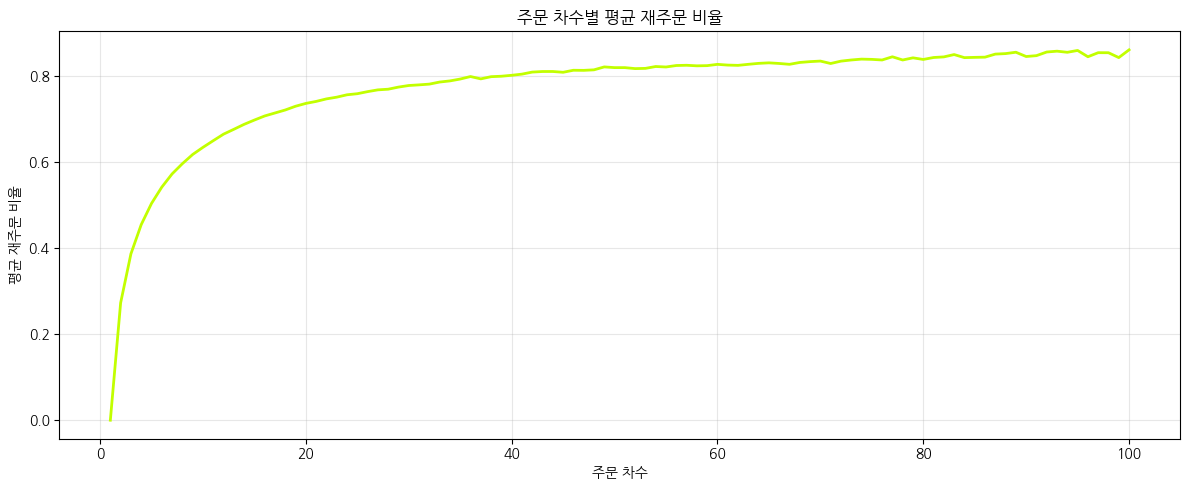

In [ ]:
order_reorder = con.execute("""
    WITH order_products AS (
        -- prior + train 주문 상품 통합
        SELECT order_id, reordered FROM prior_t
        UNION ALL
        SELECT order_id, reordered FROM train_t
    )
    -- 주문 차수별 평균 재주문 비율
    SELECT o.order_number, AVG(op.reordered) AS reorder_rate
    FROM order_products op
    JOIN orders_t o ON op.order_id = o.order_id
    GROUP BY o.order_number
    ORDER BY o.order_number
""").df().set_index('order_number')['reorder_rate']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(order_reorder.index, order_reorder.values, color=COLORS[0], linewidth=2)
ax.set_title('주문 차수별 평균 재주문 비율')
ax.set_xlabel('주문 차수')
ax.set_ylabel('평균 재주문 비율')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('h1_reorder_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 주문 차수별 재주문 비율 확인 결과

초반(1-20회) 구간에서 재주문 비율이 빠르게 상승하다가
이후 완만하게 수렴하는 형태 확인.

상승 속도가 급격히 꺾이는 지점이 존재하지만,
육안으로 정확한 임계점을 특정하기 어려움.

Kneedle 알고리즘으로 기울기 변화가 가장 큰 지점을 탐색.

Kneedle 임계점: 16회


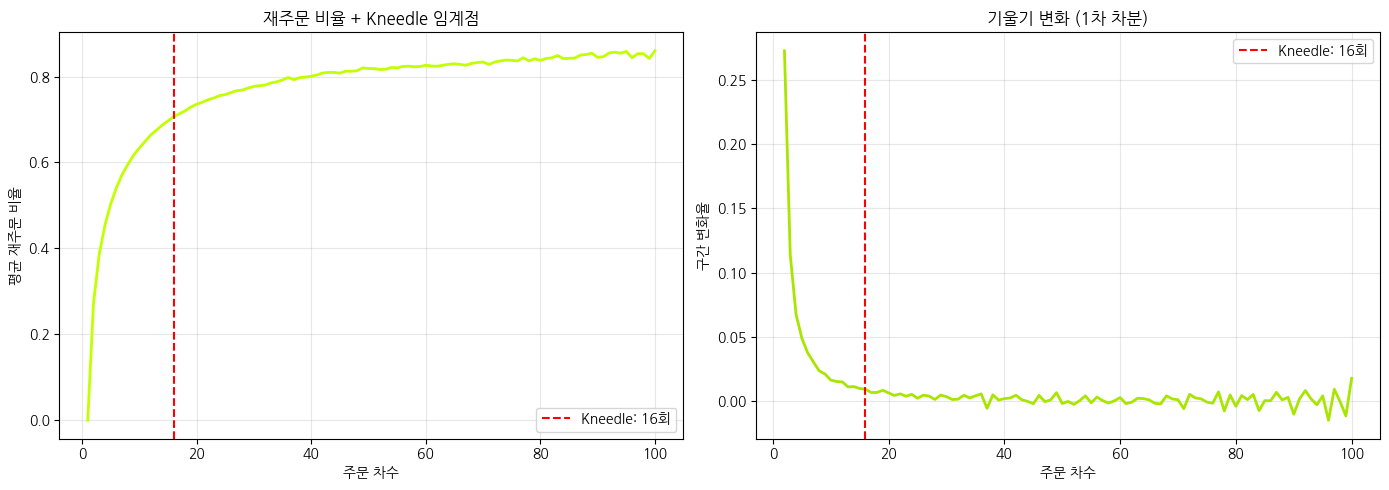

In [ ]:
from kneed import KneeLocator

kneedle = KneeLocator(order_reorder.index, order_reorder.values,
                      curve='concave', direction='increasing', S=1.0)
knee_point = kneedle.knee

print(f"Kneedle 임계점: {knee_point}회")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(order_reorder.index, order_reorder.values, color=COLORS[0], linewidth=2)
axes[0].axvline(knee_point, color='red', linestyle='--',
                label=f'Kneedle: {knee_point}회')
axes[0].set_title('재주문 비율 + Kneedle 임계점')
axes[0].set_xlabel('주문 차수')
axes[0].set_ylabel('평균 재주문 비율')
axes[0].legend()
axes[0].grid(alpha=0.3)

diff = np.diff(order_reorder.values)
axes[1].plot(order_reorder.index[1:], diff, color=COLORS[1], linewidth=2)
axes[1].axvline(knee_point, color='red', linestyle='--',
                label=f'Kneedle: {knee_point}회')
axes[1].set_title('기울기 변화 (1차 차분)')
axes[1].set_xlabel('주문 차수')
axes[1].set_ylabel('구간 변화율')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('h1_kneedle.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# S값 민감도 검증 — Kneedle 결과가 파라미터에 따라 흔들리는지 확인
for s in [0.5, 1.0, 2.0, 3.0, 5.0]:
    kl = KneeLocator(order_reorder.index, order_reorder.values,
                     curve='concave', direction='increasing', S=s)
    print(f"S={s:.1f} → {kl.knee}회")

S=0.5 → 16회
S=1.0 → 16회
S=2.0 → 16회
S=3.0 → 16회
S=5.0 → 16회


### S값 민감도 확인 결과

S값(알고리즘 민감도)을 0.5에서 5.0까지 바꿔가며 테스트해도
Kneedle이 찾는 임계점은 **16회**로 일관.
파라미터 선택에 따라 결과가 흔들리지 않는다는 뜻.

**[방법 1 결과]** 재주문율 곡선 기반 → **16회**

단, 이 방법에는 구조적 한계가 있음.
"10차 주문의 평균 재주문율"을 계산하면 → 10번 이상 주문한 고객만 포함.
5번 만에 떠난 고객은 이미 빠져있기 때문에
차수가 올라갈수록 재주문율이 높아 보이는 건
실제 행동 변화가 아니라 충성 고객만 남아서일 수 있음.

→ 생존자 편향 없는 방법으로 교차 검증.

In [ ]:
# 이탈 위험률 — user_stats.total_orders 기반 (생존자 편향 없음)
hazard_rows = []
for n in range(4, 51):  # 데이터셋 최소 4회부터
    at_risk = (user_stats['total_orders'] >= n).sum()   # N차까지 온 고객
    stopped = (user_stats['total_orders'] == n).sum()   # N차에서 멈춘 고객
    if at_risk > 0:
        hazard_rows.append({
            'order': n,
            'hazard_rate': stopped / at_risk  # 이 차수에서 이탈할 확률
        })

hazard_df = pd.DataFrame(hazard_rows)

# Kneedle — 이탈률이 빠르게 감소하다 안정되는 지점
knee_hazard = KneeLocator(
    hazard_df['order'], hazard_df['hazard_rate'],
    curve='convex', direction='decreasing', S=1.0
)
print(f"이탈 위험률 기준 임계점: {knee_hazard.knee}회")

이탈 위험률 기준 임계점: 19회


**[두 방법 비교]**
- 방법 1 (재주문율 곡선): 16회
- 방법 2 (이탈 위험률): 19회

두 방법이 서로 다른 각도에서 분석했음에도 **16-19 구간**을 공통으로 지목.
이 구간 안에 실제 전환점이 존재한다는 수렴 증거.

방법 1은 재주문율 곡선에서 변화 지점을 탐색 — 생존자 편향 가능성 있음.
방법 2는 이탈 위험률 기반으로 생존자 편향 없이 측정.
방법론적으로 더 엄밀한 방법 2의 결과를 기준으로 **THRESHOLD = 19 채택.**

In [ ]:
THRESHOLD = 19
print(f"THRESHOLD 확정: {THRESHOLD}회")
user_stats['is_long_term'] = (user_stats['total_orders'] >= THRESHOLD).astype(int)

THRESHOLD 확정: 19회


## H2. 임계점 타당성 검증

H1에서 재주문율 곡선과 이탈 위험률로 19회를 도출했지만,
두 방법 모두 주문 횟수와 연관된 지표 계열 — 같은 계열 안에서의 수렴.

주문 횟수와 완전히 무관한 지표로 교차 검증 필요.
**질문: 19회 기준으로 나눈 두 그룹이 초기 주문 간격에서도 실제로 다른가?**

주문 간격은 몇 번 주문했는지와 무관하게 계산되는 독립적 행동 지표.
여기서도 두 그룹이 유의하게 구분된다면 → 19회 기준의 타당성 확인.

분포 정규성을 가정할 수 없으므로 비모수 검정인 **Mann-Whitney U 검정**을 사용.

장기고객 중앙값: 7.0일
비장기고객 중앙값: 16.0일
효과크기 r: 0.695
p-value: 0.0000


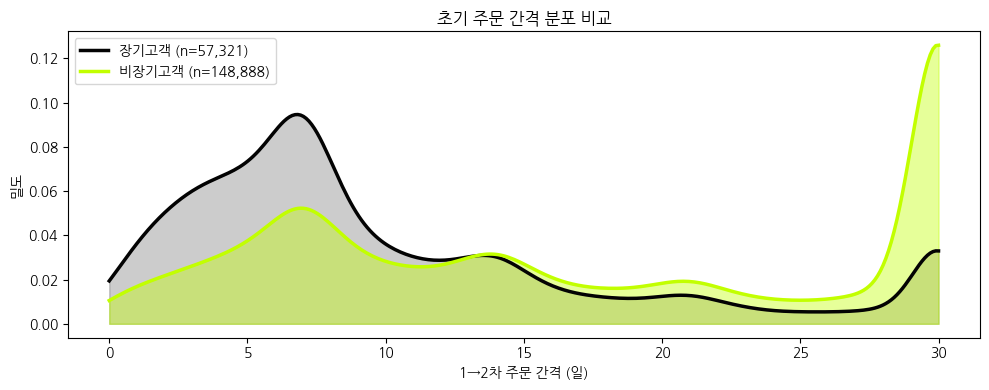

In [ ]:
from scipy.stats import mannwhitneyu, gaussian_kde
import numpy as np

# 1→2차 주문 간격 추출 + 장기/비장기 레이블 병합
order2_gap_df = duckdb.query(f"""
    SELECT user_id, days_since_prior_order AS order_gap
    FROM orders
    WHERE order_number = 2
      AND days_since_prior_order IS NOT NULL
""").df().merge(user_stats[['user_id', 'is_long_term']], on='user_id')

long_gap  = order2_gap_df[order2_gap_df['is_long_term'] == 1]['order_gap']
short_gap = order2_gap_df[order2_gap_df['is_long_term'] == 0]['order_gap']

# Mann-Whitney U 검정 (비장기 > 장기 방향)
stat, p_value = mannwhitneyu(short_gap, long_gap, alternative='greater')
n1, n2 = len(long_gap), len(short_gap)
r = stat / (n1 * n2)

print(f"장기고객 중앙값: {long_gap.median():.1f}일")
print(f"비장기고객 중앙값: {short_gap.median():.1f}일")
print(f"효과크기 r: {r:.3f}")
print(f"p-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.linspace(0, 30, 300)
ax.plot(x, gaussian_kde(long_gap)(x),  color='#030303', linewidth=2.5, label=f'장기고객 (n={n1:,})')
ax.fill_between(x, gaussian_kde(long_gap)(x),  alpha=0.2, color='#030303')
ax.plot(x, gaussian_kde(short_gap)(x), color='#C2FF00', linewidth=2.5, label=f'비장기고객 (n={n2:,})')
ax.fill_between(x, gaussian_kde(short_gap)(x), alpha=0.4, color='#C2FF00')
ax.set_xlabel('1→2차 주문 간격 (일)')
ax.set_ylabel('밀도')
ax.set_title('초기 주문 간격 분포 비교')
ax.legend()
plt.tight_layout()
plt.show()

### H2 검증 결과

- **장기고객 (19회 이상)**: 57,321명 / 초기 주문 간격 중앙값 **7.0일**
- **비장기고객 (19회 미만)**: 148,888명 / 초기 주문 간격 중앙값 **16.0일**

p-value ≈ 0 → 두 그룹 간 차이는 통계적으로 유의.
Effect size r = 0.695 → 큰 효과 크기.

19회 기준으로 나눈 두 그룹이 **초기 주문 간격에서도 뚜렷하게 구분**.
재주문율이 아닌 독립적 행동 지표에서도 차이가 확인됨 → **THRESHOLD = 19 검증 완료.**

> **[참고]**
> `days_since_prior_order` 최댓값이 30일로 기록되어 30일 이상 간격이 모두 30으로 집계되서 이상 수치 도출.

---
## H3. 조기 식별 최적 차수 탐색

THRESHOLD = 19회가 확정됐지만, 실무에서는 고객이 19회를 채울 때까지
기다릴 수 없다. 개입은 빠를수록 효과적이기 때문이다.

**질문: 초반 몇 번째 주문까지의 데이터만으로 장기고객 여부를 예측할 수 있는가?**

주문 차수를 1회부터 순차적으로 늘려가며, 해당 시점까지의 재주문 비율로
장기고객을 얼마나 정확하게 분류할 수 있는지 확인.
예측력이 수렴하는 최소 차수를 BEST_TIMING으로 정의.

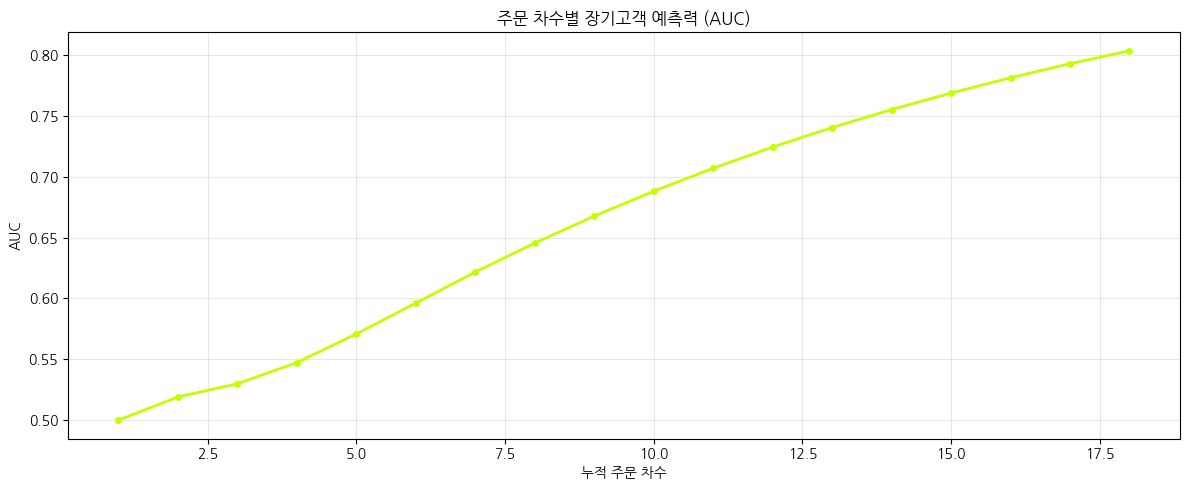

 n      auc
 1 0.500000
 2 0.519087
 3 0.529874
 4 0.547334
 5 0.570790
 6 0.596179
 7 0.621651
 8 0.645434
 9 0.667587
10 0.688009
11 0.706887
12 0.724278
13 0.740291
14 0.755091
15 0.768622
16 0.781197
17 0.792723
18 0.803367


In [ ]:
from sklearn.metrics import roc_auc_score

# 주문 차수별 누적 재주문 비율 계산
order_products = pd.concat([prior, train], ignore_index=True)
order_products = order_products.merge(orders[['order_id', 'user_id', 'order_number']], on='order_id')

auc_scores = []
for n in range(1, THRESHOLD):
    # n차까지의 누적 재주문 비율
    early_reorder = (
        order_products[order_products['order_number'] <= n]
        .groupby('user_id')['reordered']
        .mean()
        .reset_index(name='early_reorder_rate')
    )
    merged = user_stats[['user_id', 'is_long_term']].merge(early_reorder, on='user_id', how='inner')
    auc = roc_auc_score(merged['is_long_term'], merged['early_reorder_rate'])
    auc_scores.append({'n': n, 'auc': auc})

auc_df = pd.DataFrame(auc_scores)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(auc_df['n'], auc_df['auc'], color=COLORS[0], linewidth=2, marker='o', markersize=4)
ax.set_title('주문 차수별 장기고객 예측력 (AUC)')
ax.set_xlabel('누적 주문 차수')
ax.set_ylabel('AUC')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('h3_auc.png', dpi=150, bbox_inches='tight')
plt.show()

print(auc_df.to_string(index=False))

### AUC 스캔 결과

차수가 늘어날수록 AUC가 계속 올라가고 멈추는 지점이 없음.
재주문율은 주문을 많이 할수록 자연히 높아지는 지표라,
차수가 쌓일수록 예측력이 좋아 보이는 건 당연한 구조.
→ 재주문율 단일 피처로는 BEST_TIMING을 특정할 수 없음.

**접근 전환: 재주문율 → 상관계수**
"이 차수까지의 재주문율이 최종 장기전환 여부와 얼마나 관련있는가"를
차수별로 계산 — 상관관계가 빠르게 올라가다 안정되는 지점이 BEST_TIMING 후보.

/tmp/ipykernel_22949/3325197994.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(merged['early_reorder_rate'], merged['is_long_term'])


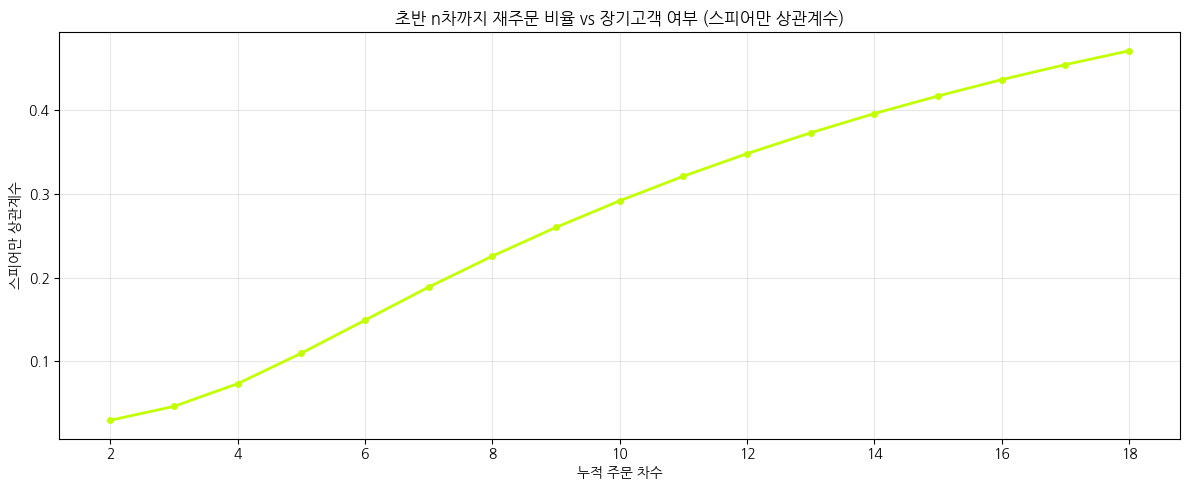

 n     corr
 1      NaN
 2 0.029827
 3 0.046373
 4 0.073461
 5 0.109862
 6 0.149264
 7 0.188795
 8 0.225705
 9 0.260084
10 0.291777
11 0.321074
12 0.348063
13 0.372914
14 0.395883
15 0.416882
16 0.436397
17 0.454285
18 0.470804


In [ ]:
from scipy.stats import spearmanr

order_products_all = con.execute("""
    SELECT order_id, reordered FROM prior_t
    UNION ALL
    SELECT order_id, reordered FROM train_t
""").df()
order_products_all = order_products_all.merge(
    orders[['order_id', 'user_id', 'order_number']], on='order_id'
)

corr_scores = []
for n in range(1, THRESHOLD):
    early_reorder = (
        order_products_all[order_products_all['order_number'] <= n]
        .groupby('user_id')['reordered']
        .mean()
        .reset_index(name='early_reorder_rate')
    )
    merged = user_stats[['user_id', 'is_long_term']].merge(early_reorder, on='user_id', how='inner')
    corr, _ = spearmanr(merged['early_reorder_rate'], merged['is_long_term'])
    corr_scores.append({'n': n, 'corr': corr})

corr_df = pd.DataFrame(corr_scores)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(corr_df['n'], corr_df['corr'], color=COLORS[0], linewidth=2, marker='o', markersize=4)
ax.set_title('초반 n차까지 재주문 비율 vs 장기고객 여부 (스피어만 상관계수)')
ax.set_xlabel('누적 주문 차수')
ax.set_ylabel('스피어만 상관계수')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('h3_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr_df.to_string(index=False))

### 스피어만 상관계수 스캔 결과

AUC 스캔과 동일한 패턴 — 차수가 늘어날수록 상관계수가 계속 올라가고 수렴 없음.
재주문율은 주문이 쌓일수록 자연히 높아지는 지표라 생기는 구조적 한계.

재주문율 기반 접근으로는 BEST_TIMING을 특정할 수 없음이 두 방법으로 확인됨.

**접근 전환: 재주문율 → 주문 간격**
재주문율 대신 주문 사이의 시간 간격을 피처로 사용.
주문 간격은 주문 횟수와 무관하게 계산되는 독립적 지표.
장기/비장기 두 그룹의 주문 간격 차이를 차수별로 비교 → BEST_TIMING 탐색.

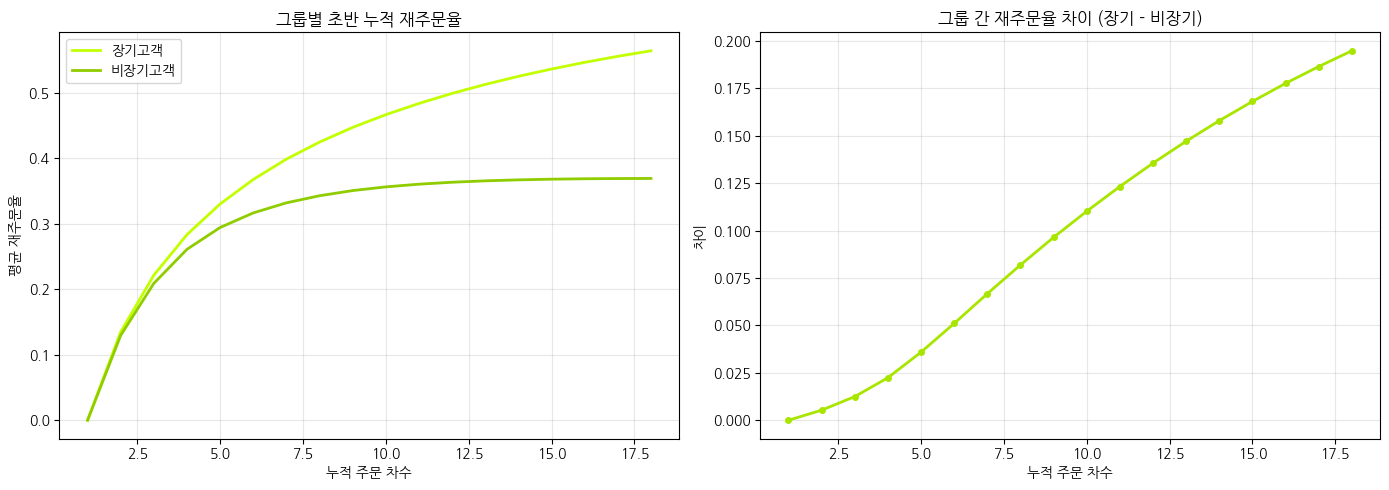

 n  long_mean  short_mean      gap
 1   0.000000    0.000000 0.000000
 2   0.134863    0.129559 0.005304
 3   0.221395    0.208932 0.012463
 4   0.283280    0.260861 0.022419
 5   0.330034    0.294138 0.035896
 6   0.367446    0.316402 0.051043
 7   0.398491    0.331775 0.066716
 8   0.424476    0.342606 0.081870
 9   0.446907    0.350493 0.096414
10   0.466327    0.356131 0.110196
11   0.483464    0.360237 0.123228
12   0.498784    0.363218 0.135565
13   0.512454    0.365339 0.147114
14   0.524815    0.366845 0.157970
15   0.535951    0.367867 0.168084
16   0.546142    0.368506 0.177636
17   0.555339    0.368856 0.186483
18   0.563777    0.368978 0.194799


In [ ]:
# 장기고객 / 비장기고객 그룹별 누적 재주문율 차이
long_term_users = user_stats[user_stats['is_long_term'] == 1]['user_id']
short_term_users = user_stats[user_stats['is_long_term'] == 0]['user_id']

gap_scores = []
for n in range(1, THRESHOLD):
    early = (
        order_products_all[order_products_all['order_number'] <= n]
        .groupby('user_id')['reordered']
        .mean()
        .reset_index(name='early_reorder_rate')
    )
    long_mean = early[early['user_id'].isin(long_term_users)]['early_reorder_rate'].mean()
    short_mean = early[early['user_id'].isin(short_term_users)]['early_reorder_rate'].mean()
    gap_scores.append({'n': n, 'long_mean': long_mean, 'short_mean': short_mean, 'gap': long_mean - short_mean})

gap_df = pd.DataFrame(gap_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 그룹별 누적 재주문율
axes[0].plot(gap_df['n'], gap_df['long_mean'], color=COLORS[0], linewidth=2, label='장기고객')
axes[0].plot(gap_df['n'], gap_df['short_mean'], color=COLORS[2], linewidth=2, label='비장기고객')
axes[0].set_title('그룹별 초반 누적 재주문율')
axes[0].set_xlabel('누적 주문 차수')
axes[0].set_ylabel('평균 재주문율')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 우: 그룹 간 차이
axes[1].plot(gap_df['n'], gap_df['gap'], color=COLORS[1], linewidth=2, marker='o', markersize=4)
axes[1].set_title('그룹 간 재주문율 차이 (장기 - 비장기)')
axes[1].set_xlabel('누적 주문 차수')
axes[1].set_ylabel('차이')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('h3_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print(gap_df.to_string(index=False))

### 그룹별 초반 누적 재주문율 비교 결과

장기고객과 비장기고객 간 재주문율 차이는 차수가 쌓일수록 계속 벌어짐.
수렴하는 지점이 없어 "이 차수부터 차이가 굳어진다"는 결론을 내리기 어려움.

앞선 두 방법(AUC 스캔, 스피어만)과 동일한 결론 —
재주문율은 주문 횟수에 따라 구조적으로 올라가는 지표라,
어느 시점이 최적인지 특정하는 데 적합하지 않음.

**접근 전환: 재주문율 → 주문 간격**
주문 간격(days_since_prior_order)은 주문 횟수와 무관하게 계산되는 독립적 지표.
두 그룹의 주문 간격이 통계적으로 유의하게 다른지, 어느 차수부터 예측력이 확보되는지 확인.

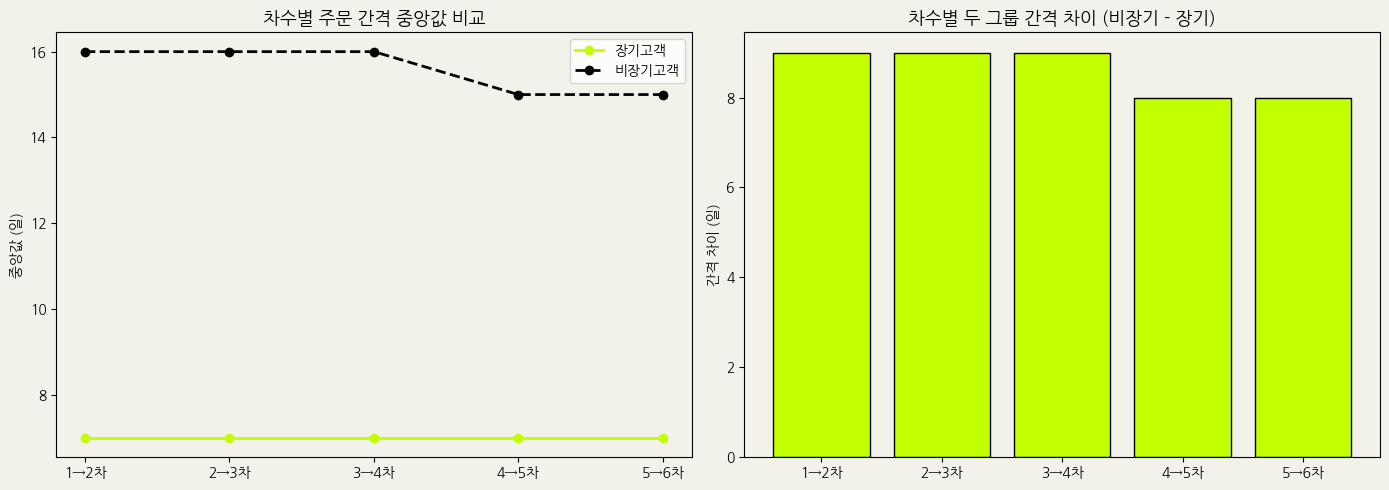


차수별 주문 간격 비교
-------------------------------------------------------
1→2차: 장기 7일 / 비장기 16일 / 차이 9일 / p=0.00e+00
2→3차: 장기 7일 / 비장기 16일 / 차이 9일 / p=0.00e+00
3→4차: 장기 7일 / 비장기 16일 / 차이 9일 / p=0.00e+00
4→5차: 장기 7일 / 비장기 15일 / 차이 8일 / p=0.00e+00
5→6차: 장기 7일 / 비장기 15일 / 차이 8일 / p=0.00e+00


In [ ]:
import duckdb
from scipy import stats
import matplotlib.pyplot as plt

interval_df = duckdb.query("""
    SELECT
        o.order_number,
        us.is_long_term,
        o.days_since_prior_order
    FROM orders o
    JOIN user_stats us ON o.user_id = us.user_id
    WHERE o.order_number BETWEEN 2 AND 6
      AND o.days_since_prior_order IS NOT NULL
""").df()

results = []
for n in range(2, 7):
    subset = interval_df[interval_df['order_number'] == n]
    long  = subset[subset['is_long_term'] == 1]['days_since_prior_order']
    short = subset[subset['is_long_term'] == 0]['days_since_prior_order']
    _, p = stats.mannwhitneyu(long, short, alternative='two-sided')
    results.append({
        'order': f"{n-1}→{n}차",
        'long_median':  long.median(),
        'short_median': short.median(),
        'gap': short.median() - long.median(),
        'p': p
    })

import pandas as pd
res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F2F2EA')

# 좌: 차수별 장기/비장기 중앙값 비교
ax1 = axes[0]
ax1.set_facecolor('#F2F2EA')
ax1.plot(res_df['order'], res_df['long_median'],
         color='#C2FF00', linewidth=2, marker='o', markersize=6, label='장기고객')
ax1.plot(res_df['order'], res_df['short_median'],
         color='#030303', linewidth=2, marker='o', markersize=6, label='비장기고객', linestyle='--')
ax1.set_title('차수별 주문 간격 중앙값 비교', color='#030303', fontsize=13)
ax1.set_ylabel('중앙값 (일)', color='#030303')
ax1.legend()
for spine in ax1.spines.values():
    spine.set_edgecolor('#030303')
ax1.tick_params(colors='#030303')

# 우: 차수별 간격 차이 (비장기 - 장기)
ax2 = axes[1]
ax2.set_facecolor('#F2F2EA')
ax2.bar(res_df['order'], res_df['gap'],
        color='#C2FF00', edgecolor='#030303', linewidth=1)
ax2.set_title('차수별 두 그룹 간격 차이 (비장기 - 장기)', color='#030303', fontsize=13)
ax2.set_ylabel('간격 차이 (일)', color='#030303')
for spine in ax2.spines.values():
    spine.set_edgecolor('#030303')
ax2.tick_params(colors='#030303')

plt.tight_layout()
plt.show()

# 수치 출력
print("\n차수별 주문 간격 비교")
print("-" * 55)
for r in results:
    print(f"{r['order']}: 장기 {r['long_median']:.0f}일 / "
          f"비장기 {r['short_median']:.0f}일 / "
          f"차이 {r['gap']:.0f}일 / p={r['p']:.2e}")

### 차수별 주문 간격 비교 결과 (Mann-Whitney U)

모든 차수(1→2차 - 5→6차)에서 p=0.00 — 장기/비장기 두 그룹은 처음부터 완전히 다른 간격을 보임.

- 장기고객: 전 구간 중앙값 **7일** 일관
- 비장기고객: 1→3차 **16일**, 4→6차 **15일**
- 두 그룹 간 차이: **8-9일**

**예상과 다른 발견**: 차이가 점점 벌어지는 게 아니라 처음부터 일정하게 유지.
1→2차 첫 주문부터 장기전환 여부가 이미 행동으로 드러나고 있다는 의미.

단, "언제 개입할 것인가"는 별개의 문제 — 차이가 크더라도 너무 이른 시점은 예측 정확도가 낮음.
→ 주문 간격을 피처로 쓴 AUC 스캔으로 예측력과 타이밍의 균형점 탐색.

 n    auc  delta
 2 0.6936 0.0000
 3 0.7467 0.0531
 4 0.7754 0.0287
 5 0.7938 0.0184
 6 0.8054 0.0116
 7 0.8169 0.0115
 8 0.8217 0.0048
 9 0.8273 0.0056
10 0.8380 0.0107

KneeLocator 수렴 시작 탐지: 5차


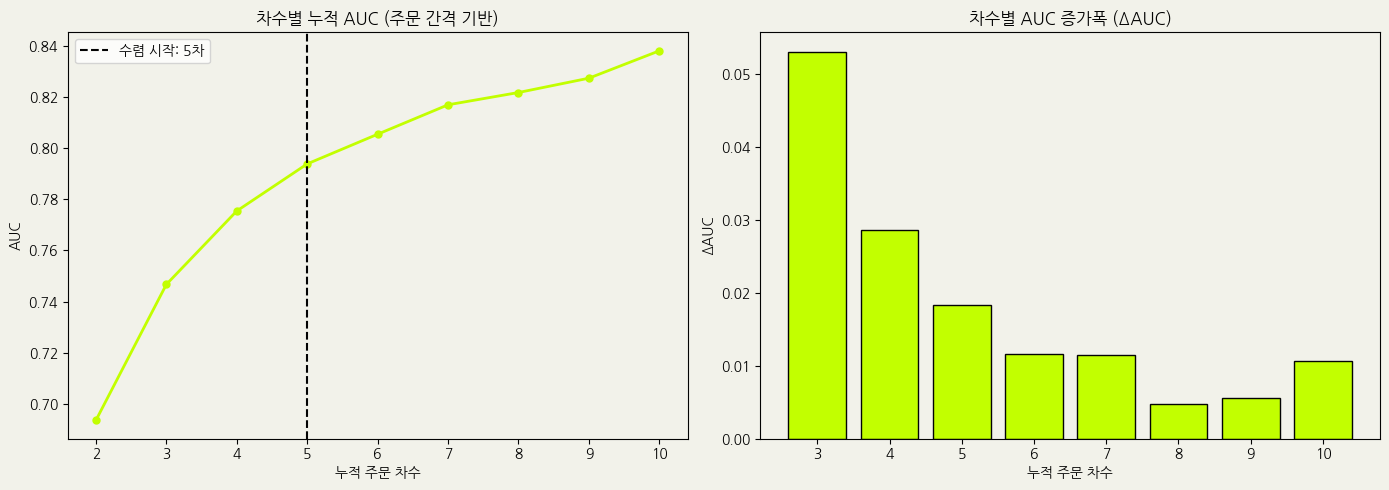

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

auc_results = []

for n in range(2, 11):
    avg_df = duckdb.query(f"""
        SELECT
            o.user_id,
            AVG(o.days_since_prior_order) AS avg_interval
        FROM orders o
        WHERE o.order_number BETWEEN 2 AND {n}
          AND o.days_since_prior_order IS NOT NULL
        GROUP BY o.user_id
    """).df()

    df = avg_df.merge(user_stats[['user_id', 'is_long_term']], on='user_id')
    X, y = df[['avg_interval']], df['is_long_term']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    sc = StandardScaler()
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(sc.fit_transform(X_train), y_train)
    auc = roc_auc_score(y_test, model.predict_proba(sc.transform(X_test))[:, 1])
    auc_results.append({'n': n, 'auc': round(auc, 4)})

auc_df = pd.DataFrame(auc_results)
auc_df['delta'] = auc_df['auc'].diff().round(4).fillna(0)

# KneeLocator — AUC 곡선 수렴 시작 지점 자동 탐지
knee = KneeLocator(
    auc_df['n'], auc_df['auc'],
    curve='concave', direction='increasing', S=1.0
)

print(auc_df[['n', 'auc', 'delta']].to_string(index=False))
print(f"\nKneeLocator 수렴 시작 탐지: {knee.knee}차")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F2F2EA')

ax1 = axes[0]
ax1.set_facecolor('#F2F2EA')
ax1.plot(auc_df['n'], auc_df['auc'],
         color='#C2FF00', linewidth=2, marker='o', markersize=5)
if knee.knee:
    ax1.axvline(knee.knee, color='#030303', linewidth=1.5,
                linestyle='--', label=f'수렴 시작: {knee.knee}차')
ax1.set_title('차수별 누적 AUC (주문 간격 기반)', color='#030303')
ax1.set_xlabel('누적 주문 차수', color='#030303')
ax1.set_ylabel('AUC', color='#030303')
ax1.legend(labelcolor='#030303')
for spine in ax1.spines.values():
    spine.set_edgecolor('#030303')
ax1.tick_params(colors='#030303')

ax2 = axes[1]
ax2.set_facecolor('#F2F2EA')
ax2.bar(auc_df['n'][1:], auc_df['delta'][1:],
        color='#C2FF00', edgecolor='#030303', linewidth=1)
ax2.set_title('차수별 AUC 증가폭 (ΔAUC)', color='#030303')
ax2.set_xlabel('누적 주문 차수', color='#030303')
ax2.set_ylabel('ΔAUC', color='#030303')
for spine in ax2.spines.values():
    spine.set_edgecolor('#030303')
ax2.tick_params(colors='#030303')

plt.tight_layout()
plt.show()

### 차수별 누적 AUC 분석 결과

2차: 0.697 → 4차: 0.780 → 10차: 0.836 — 차수가 쌓일수록 예측력 상승.
단, 증가폭은 차수가 늘수록 급격히 감소.

- 2→4차: ΔAUC 0.037-0.047 — 주문 간격 데이터가 쌓이며 예측력 빠르게 상승
- 4→5차: ΔAUC 0.011 — 증가폭 급감, 수렴 진입
- 5차 이후: ΔAUC 0.004-0.015 — 추가 차수 대비 예측력 개선 미미

**KneeLocator 수렴 시작 탐지: 4차**

4차 이후부터는 차수를 더 기다려도 예측력 개선이 크지 않음.
반면 차수가 늘어날수록 개입 타이밍은 점점 늦어짐.
→ 예측력과 개입 타이밍의 균형점: **4-6차 구간**

In [ ]:
# 개입 판단 적정 구간 정의
BEST_TIMING_MIN = 4   # 실용적 예측력 최초 확보 (AUC 0.78)
BEST_TIMING_MAX = 6   # 수렴 진입 직전 마지노선
BEST_TIMING     = 5   # 4-6차 구간 대표값 (중앙)

print(f"개입 적정 구간: {BEST_TIMING_MIN}-{BEST_TIMING_MAX}차 주문 시점")
print(f"대표값 (KneeLocator): {BEST_TIMING}차")

개입 적정 구간: 4-6차 주문 시점
대표값 (KneeLocator): 5차


## H4. 개입 시점 주문 간격 기반 장기전환 예측

H3 요약 4-6차 주문 시점 = 예측력(AUC)이 충분히 확보되면서 초기 개입이 가능한 균형 구간.
이 시점 이전은 신호가 불충분하고, 이후는 차수를 더 기다려도 AUC 개선이 미미한 반면 개입 타이밍만 늦어짐.

---

**H4 목표**
4-6차 주문 간격을 보면 "이 고객이 장기고객이 될 것인가"를 예측할 수 있는가?

---

**분석 흐름**

**① 피처 생성**
각 고객의 4-6차 주문 간격 평균을 하나의 숫자로 압축.
예: 4→5차 9일, 5→6차 11일이면 → early_avg_interval = 10.0일

**② 레이블 붙이기**
해당 고객이 실제로 장기고객이 됐는지 여부 (1 = 장기, 0 = 비장기)

**③ 로지스틱 회귀 학습**
"간격이 짧을수록 장기전환 가능성이 높다"는 패턴을 실제 데이터로 학습.
학습 후 새 고객의 간격을 넣으면 전환 확률(0-1)을 출력.
단순 yes/no가 아닌 확률로 출력하는 이유 —
고객마다 개입 우선순위가 다르게 부여되어야 하기 때문.

**④ AUC 검증**
모델이 장기/비장기 고객을 실제로 얼마나 잘 구분하는지 수치로 확인.
AUC 0.7 이상 = 실무에서 유의미한 예측력으로 판단.

**⑤ 비장기고객 전환 확률 산출**
장기고객은 이미 전환됐으므로 개입 대상 아님.
비장기고객 전원의 early_avg_interval을 모델에 입력 →
각 고객의 장기전환 확률 계산.

In [ ]:
# BEST_TIMING 구간(4-6차) 평균 주문 간격 피처 생성 — DuckDB
early_features = duckdb.query(f"""
    SELECT
        user_id,
        AVG(days_since_prior_order) AS early_avg_interval
    FROM orders
    WHERE order_number BETWEEN {BEST_TIMING_MIN} AND {BEST_TIMING_MAX}
      AND days_since_prior_order IS NOT NULL
    GROUP BY user_id
""").df()
# Mann-Whitney용 interval_df와 별개 — 로지스틱 회귀 전용 피처 테이블 생성
# 장기/비장기 레이블 병합
early_features = early_features.merge(
    user_stats[['user_id', 'is_long_term']], on='user_id', how='inner'
)

print(f"전체 고객 수: {len(early_features):,}명")
print(f"장기고객: {early_features['is_long_term'].sum():,}명")
print(f"비장기고객: {(early_features['is_long_term']==0).sum():,}명")
print(f"\nearly_avg_interval 통계:")
print(early_features.groupby('is_long_term')['early_avg_interval'].describe().round(2))

전체 고객 수: 206,209명
장기고객: 57,321명
비장기고객: 148,888명

early_avg_interval 통계:
                 count   mean   std  min    25%    50%    75%   max
is_long_term                                                       
0             148888.0  17.81  8.29  0.0  11.00  17.67  24.67  30.0
1              57321.0   9.67  5.48  0.0   5.67   8.33  13.00  30.0


In [ ]:
X = early_features[['early_avg_interval']]
y = early_features['is_long_term']

# 80/20 분할, stratify로 장기/비장기 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 로지스틱 회귀는 피처 스케일에 민감 — 표준화 적용
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_sc, y_train)

auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1])
print(f"AUC-ROC: {auc:.4f}")

# 비장기고객만 전환 확률 산출 — 장기고객은 이미 전환됐으므로 개입 대상 아님
non_converters = early_features[early_features['is_long_term'] == 0].copy()
non_converters['conversion_prob'] = model.predict_proba(
    scaler.transform(non_converters[['early_avg_interval']])
)[:, 1]

total_non_converters = len(non_converters)  # H6에서 재사용

print(f"\n비장기고객 수: {total_non_converters:,}명")
print(f"전환 확률 평균: {non_converters['conversion_prob'].mean():.3f}")
print(f"전환 확률 분포:\n{non_converters['conversion_prob'].describe().round(3)}")


AUC-ROC: 0.7784

비장기고객 수: 148,888명
전환 확률 평균: 0.224
전환 확률 분포:
count    148888.000
mean          0.224
std           0.185
min           0.030
25%           0.064
50%           0.166
75%           0.353
max           0.743
Name: conversion_prob, dtype: float64


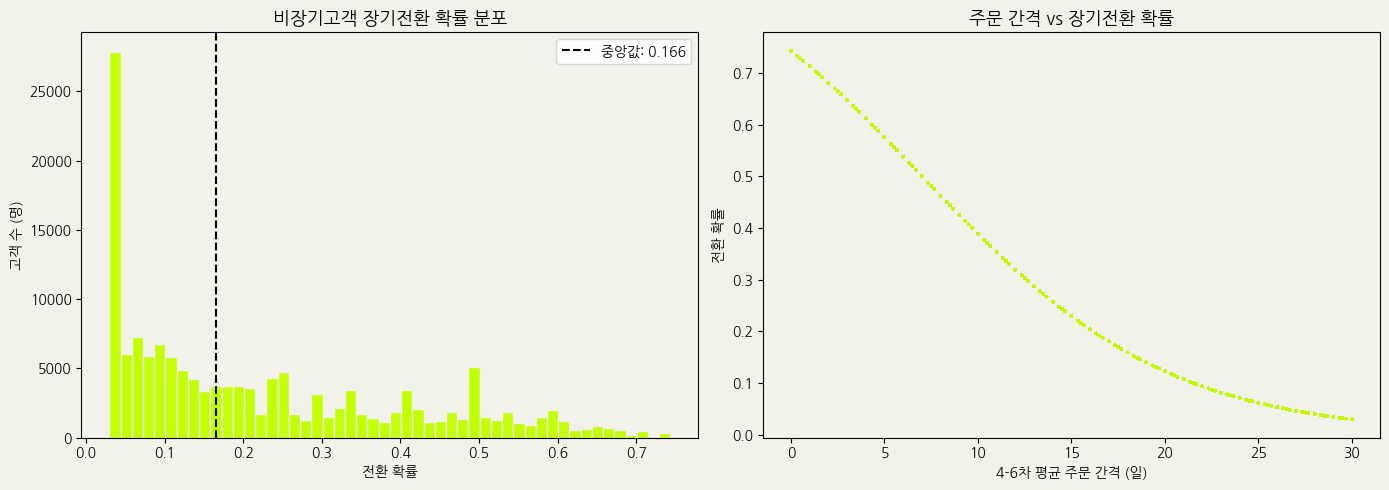

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F2F2EA')

# 좌: 비장기고객 전환 확률 분포 (고객 수 기준)
ax1 = axes[0]
ax1.set_facecolor('#F2F2EA')
ax1.hist(non_converters['conversion_prob'], bins=50,
         color='#C2FF00', edgecolor='#F2F2EA', density=False)
ax1.axvline(non_converters['conversion_prob'].median(),
            color='#030303', linewidth=1.5, linestyle='--',
            label=f"중앙값: {non_converters['conversion_prob'].median():.3f}")
ax1.set_title('비장기고객 장기전환 확률 분포', color='#030303', fontsize=13)
ax1.set_xlabel('전환 확률', color='#030303')
ax1.set_ylabel('고객 수 (명)', color='#030303')
ax1.legend(labelcolor='#030303')
for spine in ax1.spines.values():
    spine.set_edgecolor('#030303')
ax1.tick_params(colors='#030303')

# 우: 주문 간격 vs 전환 확률 관계
ax2 = axes[1]
ax2.set_facecolor('#F2F2EA')
ax2.scatter(non_converters['early_avg_interval'],
            non_converters['conversion_prob'],
            color='#C2FF00', alpha=0.3, s=5, edgecolors='none')
ax2.set_title('주문 간격 vs 장기전환 확률', color='#030303', fontsize=13)
ax2.set_xlabel('4-6차 평균 주문 간격 (일)', color='#030303')
ax2.set_ylabel('전환 확률', color='#030303')
for spine in ax2.spines.values():
    spine.set_edgecolor('#030303')
ax2.tick_params(colors='#030303')

plt.tight_layout()
plt.show()

### H4 결과: 4-6차 주문 간격 기반 장기전환 예측

**AUC-ROC 0.778** — 4-6차 평균 주문 간격 단일 피처만으로 유의미한 예측력 확보.

**전환 확률 분포 (비장기고객 148,888명)**
- 평균: 0.224 / 중앙값: 0.166
- 25%: 0.064 / 75%: 0.353

간격이 짧을수록 전환 확률이 높고, 길수록 낮음.
→ H5: "몇 일을 기준으로 개입할 것인가" 수치로 정의.

## H5. 개입 시점 정의

H4에서 확인: 주문 간격이 짧을수록 장기전환 확률이 상승.
"몇 일이 기준인가"는 시각적 판단으로 특정 불가.

**핵심 질문: 몇 일을 기준으로 리스크 고객을 판별할 것인가?**

ROC curve에서 민감도(장기고객을 장기고객으로 맞춘 비율)와
특이도(비장기고객을 비장기고객으로 맞춘 비율)를
동시에 최대화하는 지점을 최적 임계값으로 선택.

해당 임계값에 대응하는 주문 간격을 역산 →
"4-6차 평균 주문 간격이 X일을 초과하면 리스크 고객" 개입 시점 수치화.

최적 임계값 (전환 확률): 0.267
민감도: 0.780
특이도: 0.652

개입 시점: 4-6차 평균 주문 간격 13.7일 초과


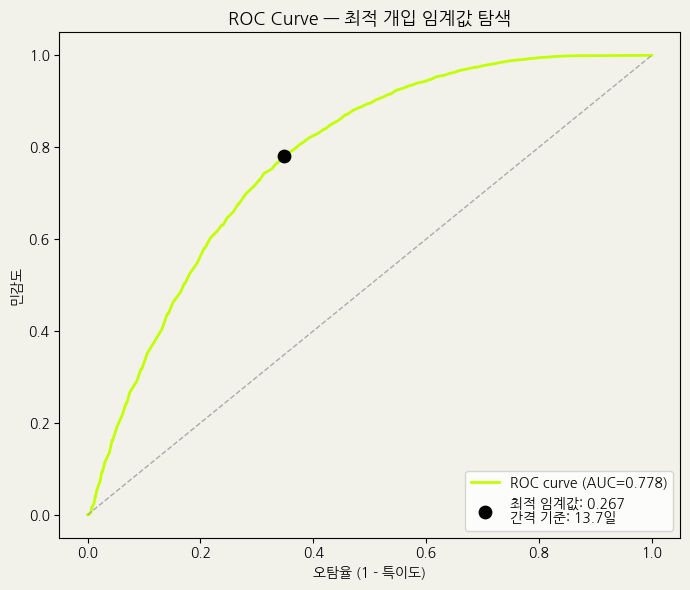

In [ ]:
from sklearn.metrics import roc_curve

# 테스트셋 예측 확률
y_prob = model.predict_proba(X_test_sc)[:, 1]

# 임계값별 오탐율(fpr), 민감도(tpr), 임계값 목록
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 민감도 + 특이도 동시 최대화 지점 탐색
# 특이도 = 1 - fpr
optimal_idx = (tpr + (1 - fpr)).argmax()
optimal_threshold = thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

print(f"최적 임계값 (전환 확률): {optimal_threshold:.3f}")
print(f"민감도: {optimal_tpr:.3f}")
print(f"특이도: {1 - optimal_fpr:.3f}")

# 최적 임계값에 대응하는 주문 간격 역산
# 모델: prob = sigmoid(w * scaled_interval + b)
# scaled_interval = (interval - mean) / std → interval 역산
import numpy as np

log_odds = np.log(optimal_threshold / (1 - optimal_threshold))
scaled_val = (log_odds - model.intercept_[0]) / model.coef_[0][0]
# 표준화 역변환
interval_threshold = scaled_val * scaler.scale_[0] + scaler.mean_[0]

print(f"\n개입 시점: 4-6차 평균 주문 간격 {interval_threshold:.1f}일 초과")

# 시각화
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#F2F2EA')
ax.set_facecolor('#F2F2EA')

ax.plot(fpr, tpr, color='#C2FF00', linewidth=2, label=f'ROC curve (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], color='#AAAAAA', linewidth=1, linestyle='--')
ax.scatter(optimal_fpr, optimal_tpr, color='#030303', s=80, zorder=5,
           label=f'최적 임계값: {optimal_threshold:.3f}\n간격 기준: {interval_threshold:.1f}일')

ax.set_title('ROC Curve — 최적 개입 임계값 탐색', color='#030303', fontsize=13)
ax.set_xlabel('오탐율 (1 - 특이도)', color='#030303')
ax.set_ylabel('민감도', color='#030303')
ax.legend(labelcolor='#030303', loc='lower right')
for spine in ax.spines.values():
    spine.set_edgecolor('#030303')
ax.tick_params(colors='#030303')

plt.tight_layout()
plt.show()

### 개입 상한선 탐색

하한선(13.7일)으로 개입 시작점은 확정됐지만,
간격이 지나치게 긴 고객은 이미 이탈에 가까운 상태 — 마케팅 반응 기대 어려움.

**이탈 고객군의 경계를 데이터로 특정하기 위해**

비장기고객 148,888명의 전환확률을 분포로 보면,
대부분의 고객이 특정 전환확률 구간에 몰려있다가
어느 지점을 넘으면 해당 전환확률을 가진 고객 수가 급격히 줄어듦.
그 경계 지점이 자연스러운 상한선.

→ 고객 수가 급격히 줄어드는 지점을 자동 탐지.
그 전환확률(16.4%)에 해당하는 주문 간격이 몇 일인지
모델 수식을 거꾸로 풀어 도출 → **17.8일**

In [ ]:
from scipy.stats import gaussian_kde

# 비장기고객 전환확률 분포 — 구간별 고객 수 곡선 추정
probs = non_converters['conversion_prob'].values
prob_curve = gaussian_kde(probs)

x = np.linspace(probs.min(), probs.max(), 500)
freq_curve = prob_curve(x)  # 각 전환확률 구간에 고객이 얼마나 몰려있는지

# 고객이 가장 몰린 지점 이후 — 고객 수가 급감하는 변곡점 탐지
peak_idx = np.argmax(freq_curve)
x_after  = x[peak_idx:]
freq_after = freq_curve[peak_idx:]

knee = KneeLocator(x_after, freq_after, curve='convex', direction='decreasing', S=1.0)
upper_prob = knee.knee

# 해당 전환확률 → 주문 간격으로 역산
log_odds_upper = np.log(upper_prob / (1 - upper_prob))
scaled_upper   = (log_odds_upper - model.intercept_[0]) / model.coef_[0][0]
upper_interval = scaled_upper * scaler.scale_[0] + scaler.mean_[0]

print(f"상한선 기준 전환확률 : {upper_prob:.3f} ({upper_prob*100:.1f}%)")
print(f"대응 주문 간격       : {upper_interval:.1f}일")
print(f"\n개입 구간: {interval_threshold:.1f}일 초과 - {upper_interval:.1f}일 이하")

상한선 기준 전환확률 : 0.164 (16.4%)
대응 주문 간격       : 17.8일

개입 구간: 13.7일 초과 - 17.8일 이하


### 결과

**하한선 — ROC Curve 최적 임계값**
- 최적 전환확률 기준선: **0.267 (26.7%)**
- 대응 주문 간격: **13.7일 초과**
- 장기전환 고객 포착률: 78.0%
- 비대상 고객 제외율: 65.2%

**상한선 — 전환확률 분포 변곡점**
- 고객 수 급감 지점 전환확률: **0.164 (16.4%)**
- 대응 주문 간격: **17.8일 이하**

### 해석
- 13.7일 초과: 전환확률 26.7% 미만 — 그대로 두면 장기전환 가능성 낮음, 개입 시작
- 17.8일 초과: 전환확률 16.4% 미만 — 이미 이탈에 가까운 상태, 개입 효과 기대 어려움

> **개입 구간: 4-6차 주문 간 평균 간격 13.7일 초과 - 17.8일 이하**

> **[한계]** `days_since_prior_order` 최댓값 30일 절단.
> 17.8일 상한선은 이 제약 안에서 도출된 값.
> 실제 이탈 고객 간격이 30일을 초과하는 경우가 많다면 상한선이 과소 추정될 수 있음.

## H6. 결론 및 마케팅 제언

---

### 분석 결론
신규 고객의 초기 주문 간격은 장기전환 여부를 예측하는 핵심 신호.
- 장기고객: 초기부터 짧은 간격 유지 (중앙값 7일)
- 비장기고객: 초기부터 긴 간격 (중앙값 16-17일)
- 두 그룹의 차이는 1→2차 주문부터 이미 유의미하게 존재

**4-6차 주문 구간**이 예측력과 개입 타이밍의 균형점.
이 구간의 평균 주문 간격 하나만으로 AUC 0.778 달성.

### 개입 대상 정의
- 하한선 13.7일 초과: 장기전환 확률 26.7% 미만
- 상한선 17.8일 이하: 장기전환 확률 16.4% 초과

> 4-6차 주문 간 평균 간격 13.7일 초과 - 17.8일 이하 비장기고객
> 전체 비장기고객 148,888명 중 23,535명 (15.8%) 해당

### 마케팅 제언
시점: 4-6차 주문 직후, 간격 모니터링
대상: 평균 주문 간격 13.7일 초과 - 17.8일 이하 고객
방향: 주문 빈도를 높이는 방향의 개입 (재구매 유도 쿠폰, 타이밍 리마인더,instacart 구독화 무료체험 등)

### 다음 단계
개입 대상 고객군 식별까지 완료.
실제 마케팅 효과는 A/B 테스트를 통한 검증 필요.
- 개입 시점: 4-6차 주문 간격 13.7일 초과 감지 시점
- 측정 지표: 장기전환율 변화, 이후 평균 주문 간격 변화
- 피처 확장 검토: 상품 다양성, 재구매 카테고리, 첫 주문 시간대 등 추가 피처로
  AUC 개선 여지 탐색 (현재 단일 피처 기준 0.778)

In [ ]:
# 개입 대상 고객 수 산출 (13.7일 초과 - 17.8일 이하)
target_refined = duckdb.query(f"""
    SELECT COUNT(*) AS target_count
    FROM (
        SELECT user_id, AVG(days_since_prior_order) AS early_avg_interval
        FROM orders
        WHERE order_number BETWEEN {BEST_TIMING_MIN} AND {BEST_TIMING_MAX}
          AND days_since_prior_order IS NOT NULL
        GROUP BY user_id
    ) sub
    JOIN user_stats us USING (user_id)
    WHERE us.is_long_term = 0
      AND early_avg_interval > {interval_threshold:.1f}
      AND early_avg_interval <= {upper_interval:.1f}
""").df()

refined_count = target_refined['target_count'].values[0]

print(f"전체 비장기고객 수       : {total_non_converters:,}명")
print(f"개입 대상 고객 수        : {refined_count:,}명")
print(f"비장기고객 중 개입 대상  : {refined_count / total_non_converters * 100:.1f}%")

전체 비장기고객 수       : 148,888명
개입 대상 고객 수        : 23,535명
비장기고객 중 개입 대상  : 15.8%
